# Joey's Individual Notebook: Crime and Safety

## Introduction

The goal of this project is to determine the best neighborhood in Pittsburgh using data-driven analysis.

For my portion of the project, I focus on safety. Safety is an important factor when evaluating neighborhoods because areas with lower crime rates are generally more desirable places to live.

To measure safety, I use crime data from the Western Pennsylvania Regional Data Center, specifically the Monthly Criminal Activity dataset covering the years 2024–2026.

## The Metric: Safety Based on Crime

I define safety using the total number of reported crime incidents in each neighborhood.

Neighborhoods with fewer crimes are considered safer. To measure this, I count how many incidents occur in each neighborhood and rank them from lowest to highest.

The neighborhood with the lowest number of reported incidents is considered the safest.

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

In [49]:
df = pd.read_csv("data/crime.csv", low_memory=False)
df.head()

,_id,Report_Number,ReportedDate,ReportedTime,Hour,DayofWeek,ReportedMonth,NIBRS_Coded_Offense,NIBRS_Offense_Code,NIBRS_Offense_Category,NIBRS_Offense_Type,NIBRS_Crime_Against,NIBRS_Offense_Grouping,Violation,XCOORD,YCOORD,Zone,Tract,Neighborhood,Block_Address
0,1,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,13A AGGRAVATED ASSAULT,13A,Assault Offenses,Aggravated Assault,Person,A,18 2718 A1 Strangulation Basic - Applying,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
1,2,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,13C INTIMIDATION,13C,Assault Offenses,Intimidation,Person,A,18 2706 A1 Terroristic Threats-General,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
2,3,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,90Z ALL OTHER OFFENSES,90Z,All other Offenses,All other Offenses,Group B,B,75 3733 A Fleeing or Attempting To Elude Polic...,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
3,4,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,23H ALL OTHER LARCENY,23H,Larceny/Theft Offenses,All Other Larceny,Property,A,18 3921 A Theft by Unlawful Taking-Movable – L...,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
4,5,PGHP24000017,2024-01-01,00:21,0,Monday,Jan,9999 Vehicle Offense (Not NIBRS Reportable),999,Not NIBRS Reportable,Not NIBRS Reportable,Group B,B,LO 6 101 Discharge of Firearms Prohibited,-80.0243,40.4582,Zone 1,2107,Manchester,"1200 Block of COLUMBUS AVE Pittsburgh, PA"


In [50]:
print(df.shape)
print(df.columns.tolist())

(89038, 20)
['_id', 'Report_Number', 'ReportedDate', 'ReportedTime', 'Hour', 'DayofWeek', 'ReportedMonth', 'NIBRS_Coded_Offense', 'NIBRS_Offense_Code', 'NIBRS_Offense_Category', 'NIBRS_Offense_Type', 'NIBRS_Crime_Against', 'NIBRS_Offense_Grouping', 'Violation', 'XCOORD', 'YCOORD', 'Zone', 'Tract', 'Neighborhood', 'Block_Address']


## Data Preparation

To analyze safety, I focus on the neighborhood column from the dataset. I remove any missing values and prepare the data for counting crime incidents per neighborhood.

In [51]:
crime_df = df[['Neighborhood']].dropna()
crime_df.head()

,Neighborhood
0,Brookline
1,Brookline
2,Brookline
3,Brookline
4,Manchester


## Analysis

Next, I count the number of crime incidents in each neighborhood. This allows me to compare neighborhoods based on total crime counts.

In [52]:
crime_df['Neighborhood'] = crime_df['Neighborhood'].replace({
    'St. Clair': 'Saint Clair'
})

In [53]:
crime_counts = crime_df['Neighborhood'].value_counts().reset_index()
crime_counts.columns = ['Neighborhood', 'Crime Count']

crime_counts = crime_counts.sort_values(by='Crime Count')
crime_counts.head(10)

,Neighborhood,Crime Count
92,Chartiers City,5
91,Saint Clair,37
90,Ridgemont,40
89,Chartiers,49
88,New Homestead,61
87,Swisshelm Park,76
86,East Carnegie,80
85,Summer Hill,94
84,Spring Hill-City View,103
83,Esplen,104


## Visualization

The chart below shows the top 10 safest neighborhoods based on the lowest number of reported crime incidents.

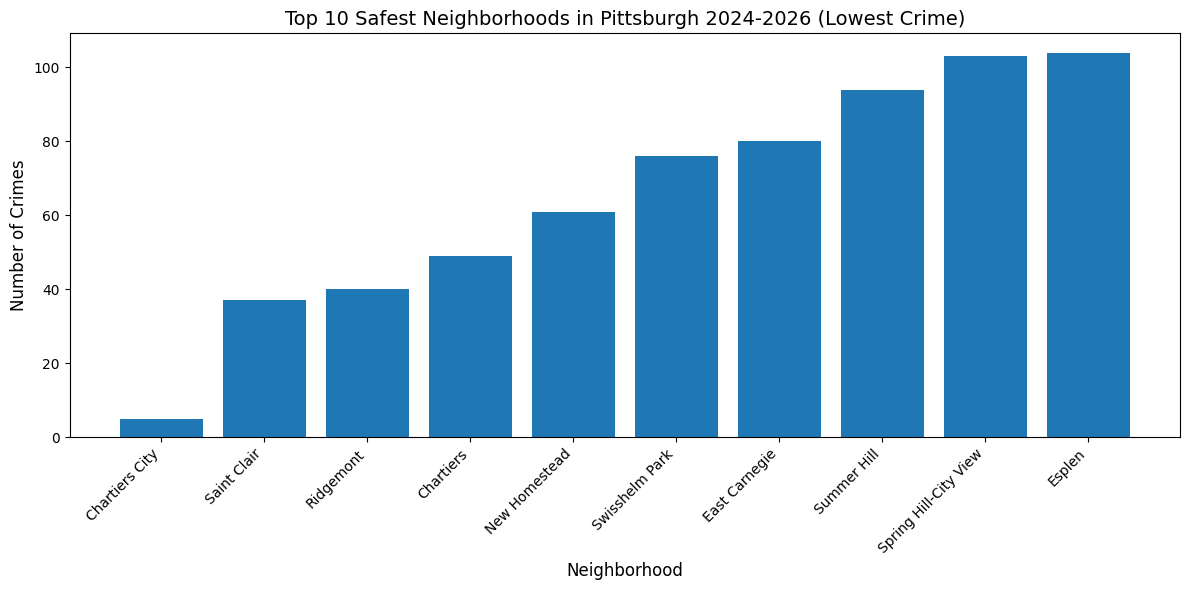

In [54]:
top10_safe = crime_counts.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10_safe['Neighborhood'], top10_safe['Crime Count'])

plt.title('Top 10 Safest Neighborhoods in Pittsburgh 2024-2026 (Lowest Crime)', fontsize=14)
plt.xlabel('Neighborhood', fontsize=12)
plt.ylabel('Number of Crimes', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

The chart above shows the 10 neighborhoods with the lowest crime counts. These neighborhoods are considered the safest based on the data.

In [55]:
safest = crime_counts.iloc[0]

print("Safest neighborhood:", safest['Neighborhood'])
print("Crime count:", safest['Crime Count'])

Safest neighborhood: Chartiers City
Crime count: 5


## Results

After analyzing the data from 2024–2026, I found that **Chartiers City** has the lowest number of reported crime incidents.

This means that **Chartiers City** is the safest neighborhood in Pittsburgh based on my metric during this time period.

The chart also shows other neighborhoods with relatively low crime counts, allowing for comparison.

## Conclusion

Based on my analysis, safety is an important factor in determining the best neighborhood.

Using crime data from 2024–2026, I found that **Chartiers City** is the safest neighborhood.

Although safety is only one part of the overall project, it provides valuable insight into neighborhood quality and helps support our group’s final decision.

These results reflect crime patterns during the 2024–2026 time period and may change over time.